<a href="https://colab.research.google.com/github/drahulnayak/EEG-Signal-Classification/blob/main/Copy_of__1_Final_Project_submission_of_Rahul_on_EEG_signal_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd

df = pd.read_csv("s00.csv")
print(df.shape)
print(df.head())

(30999, 19)
     4.476  -2.7403  -2.5017  0.095121  -7.0917  -0.42704  -2.5918  -3.3238  \
0   1.2080  -3.3088  -4.4178  -0.52935  -8.5782   0.40699  -3.0996  -3.6005   
1  -2.5460  -3.7083  -6.4109  -1.00330 -10.2200   1.87700  -3.6952  -3.8673   
2  -6.1871  -3.6804  -8.0297  -1.10310 -11.7210   4.01570  -4.2652  -4.0530   
3  -9.1110  -3.0027  -8.8444  -0.65140 -12.7840   6.71770  -4.6708  -4.0965   
4 -10.8820  -1.5795  -8.5962   0.41845 -13.1950   9.74310  -4.7778  -3.9759   

     0.9995  0.87011  -0.080058  2.8075  -0.52398   1.9341  -3.7614  -1.144  \
0 -0.048363 -0.17258  -0.129650  3.2872   -1.0667  1.53570  -5.1933 -2.2263   
1 -1.132300 -1.32850  -0.094006  3.9756   -1.6743  1.12850  -6.5565 -3.0953   
2 -1.984100 -2.36070   0.076473  4.8331   -2.2293  0.79364  -7.4787 -3.4209   
3 -2.337200 -3.02550   0.401930  5.7805   -2.6145  0.58741  -7.6430 -2.9829   
4 -2.021600 -3.15980   0.869980  6.7141   -2.7528  0.50809  -6.9019 -1.7585   

   0.033687  2.7164  0.84831  
0  -0.6

In [21]:
!pip install deap gdown lightgbm xgboost catboost imbalanced-learn

#DEAP is a Genetic algorithm

In [22]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.feature_selection import VarianceThreshold
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from concurrent.futures import ThreadPoolExecutor, TimeoutError


In [23]:
import numpy as np
import scipy.io
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from deap import base, creator, tools, algorithms
import random

In [24]:
# ===== STEP: LOAD SUBJECT INFO & CREATE 3-CLASS LABEL MAP =====

import pandas as pd
import numpy as np

subject_info = pd.read_csv("subject-info.csv")

subject_info.columns = subject_info.columns.str.strip().str.lower()

sub_values = subject_info['number of subtractions']

low_th = np.percentile(sub_values, 33)
high_th = np.percentile(sub_values, 66)

subject_to_label = {}

for _, row in subject_info.iterrows():
    subject_name = row['subject']
    value = row['number of subtractions']

    subject_id = subject_name.replace("Subject", "s").lower()

    if value <= low_th:
        label = 0
    elif value <= high_th:
        label = 1
    else:
        label = 2

    subject_to_label[subject_id] = label

print("Mapping created successfully!")
print(list(subject_to_label.items())[:5])

Mapping created successfully!
[('s00', 0), ('s01', 2), ('s02', 1), ('s03', 2), ('s04', 0)]


In [25]:
# ===== STEP: LOAD EEG DATA WITH REAL 3-CLASS LABELS (ROOT DIRECTORY) =====

import os
import pandas as pd
import numpy as np

data_folder = "/content"   # 🔥 FIXED

print("Files in folder:", os.listdir(data_folder))

all_data = []
all_labels = []

for file in os.listdir(data_folder):
    if file.endswith(".csv") and file.startswith("s"):

        file_path = os.path.join(data_folder, file)

        print("Reading:", file)

        df = pd.read_csv(file_path)
        signal = df.values

        subject_id = file.split(".")[0].lower()

        if subject_id in subject_to_label:
            label = subject_to_label[subject_id]
        else:
            print("Skipping:", subject_id)
            continue

        all_data.append(signal)
        all_labels.append(label)

# Convert to numpy
all_data = np.array(all_data, dtype=object)
all_labels = np.array(all_labels, dtype=int)

print("\nTotal samples:", len(all_data))
print("Labels shape:", all_labels.shape)

if len(all_labels) > 0:
    print("Sample label distribution:", np.bincount(all_labels))
else:
    print("No labels found ❌")

Files in folder: ['.config', 's26.csv', 's11.csv', 's35.csv', 's18.csv', 's25.csv', 's14.csv', 's15.csv', 's24.csv', 's23.csv', 's00.csv', 's20.csv', 's05.csv', 's06.csv', 's10.csv', 's33.csv', 's13.csv', 's27.csv', 's01.csv', 's03.csv', 's04.csv', 's02.csv', 's08.csv', 'subject-info.csv', 's16.csv', 's31.csv', 's09.csv', 's32.csv', 's19.csv', 's22.csv', 's34.csv', 's21.csv', 's12.csv', 's28.csv', 's17.csv', 's29.csv', 's30.csv', 's07.csv', 'sample_data']
Reading: s26.csv
Reading: s11.csv
Reading: s35.csv
Reading: s18.csv
Reading: s25.csv
Reading: s14.csv
Reading: s15.csv
Reading: s24.csv
Reading: s23.csv
Reading: s00.csv
Reading: s20.csv
Reading: s05.csv
Reading: s06.csv
Reading: s10.csv
Reading: s33.csv
Reading: s13.csv
Reading: s27.csv
Reading: s01.csv
Reading: s03.csv
Reading: s04.csv
Reading: s02.csv
Reading: s08.csv
Reading: subject-info.csv
Skipping: subject-info
Reading: s16.csv
Reading: s31.csv
Reading: s09.csv
Reading: s32.csv
Reading: s19.csv
Reading: s22.csv
Reading: s34.cs

In [26]:
# ===== STEP: WINDOW SEGMENTATION + LABEL EXPANSION =====

window_size = 1000   # 2 seconds (500Hz)
step_size = 500      # 50% overlap

X = []
y = []

for signal, label in zip(all_data, all_labels):

    num_samples = signal.shape[0]

    for start in range(0, num_samples - window_size, step_size):
        end = start + window_size

        window = signal[start:end]

        X.append(window)
        y.append(label)

# Convert to numpy
X = np.array(X)
y = np.array(y)

print("Final dataset shape:", X.shape)
print("Final labels shape:", y.shape)
print("Label distribution:", np.bincount(y))

Final dataset shape: (2160, 1000, 19)
Final labels shape: (2160,)
Label distribution: [720 720 720]


In [27]:
# ===== STEP: FEATURE EXTRACTION FROM WINDOWS =====

import numpy as np
from scipy.signal import welch

def bandpower(data, sf=500, band=(8, 13)):
    f, Pxx = welch(data, sf, nperseg=256)
    idx = np.logical_and(f >= band[0], f <= band[1])
    return np.sum(Pxx[idx])

def extract_features(window):
    features = []

    for ch in range(window.shape[1]):
        signal = window[:, ch]

        # Statistical features
        features.append(np.mean(signal))
        features.append(np.std(signal))
        features.append(np.min(signal))
        features.append(np.max(signal))

        # Frequency features
        features.append(bandpower(signal, band=(4, 8)))   # theta
        features.append(bandpower(signal, band=(8, 13)))  # alpha
        features.append(bandpower(signal, band=(13, 30))) # beta

    return features

# Apply feature extraction
X_features = np.array([extract_features(w) for w in X])

print("Feature shape:", X_features.shape)
print("Labels shape:", y.shape)

Feature shape: (2160, 133)
Labels shape: (2160,)


In [28]:
# ===== STEP: TRAINING PIPELINE =====

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
model = RandomForestClassifier(n_estimators=200, random_state=42)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9282407407407407

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93       144
           1       0.95      0.91      0.93       144
           2       0.92      0.94      0.93       144

    accuracy                           0.93       432
   macro avg       0.93      0.93      0.93       432
weighted avg       0.93      0.93      0.93       432


Confusion Matrix:
 [[135   5   4]
 [  5 131   8]
 [  7   2 135]]


Accuracy: 0.9282407407407407


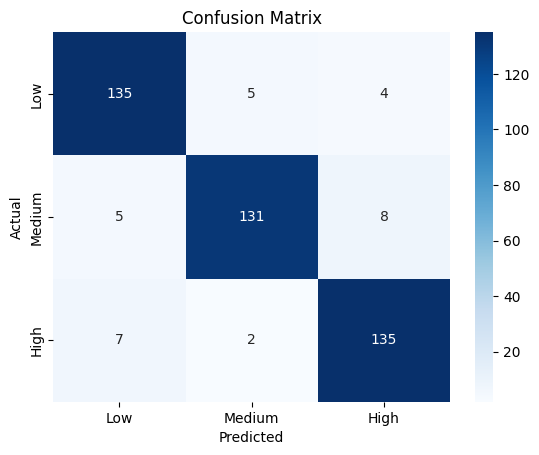

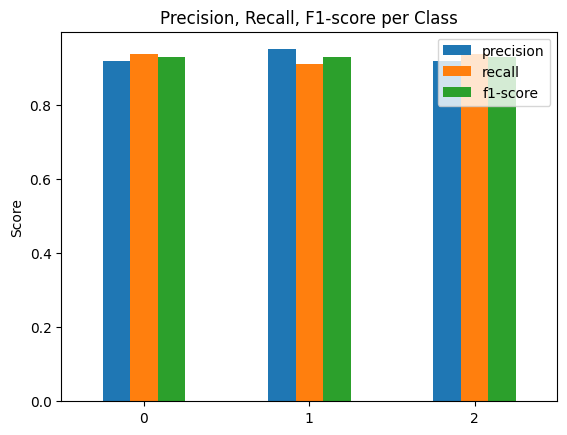

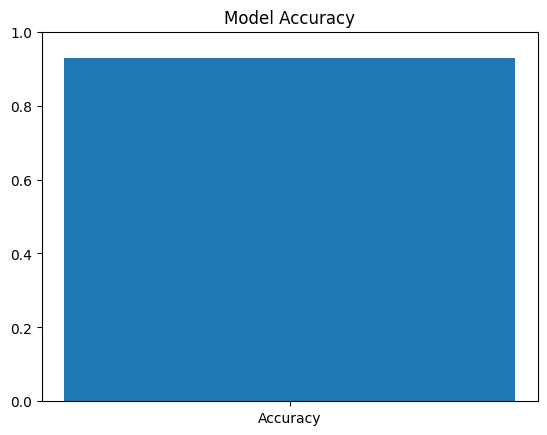

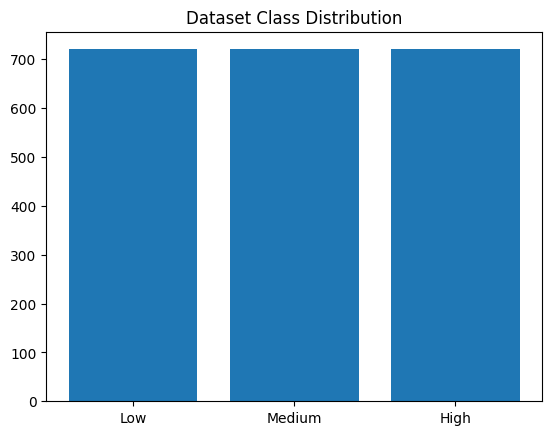

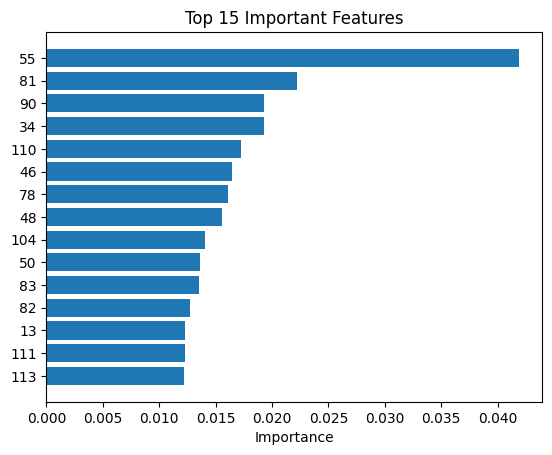

In [29]:
# ===== STEP: VISUALIZATION FOR RESULTS =====

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import pandas as pd

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# ===== 1. CONFUSION MATRIX HEATMAP =====
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ===== 2. CLASSIFICATION REPORT BAR PLOT =====
report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# Remove accuracy/support rows
df_plot = df_report.iloc[:3][['precision', 'recall', 'f1-score']]

df_plot.plot(kind='bar')
plt.title("Precision, Recall, F1-score per Class")
plt.xticks(rotation=0)
plt.ylabel("Score")
plt.show()


# ===== 3. ACCURACY BAR =====
plt.figure()
plt.bar(["Accuracy"], [acc])
plt.ylim(0,1)
plt.title("Model Accuracy")
plt.show()


# ===== 4. CLASS DISTRIBUTION =====
plt.figure()
unique, counts = np.unique(y, return_counts=True)
plt.bar(["Low", "Medium", "High"], counts)
plt.title("Dataset Class Distribution")
plt.show()


# ===== 5. FEATURE IMPORTANCE (RANDOM FOREST) =====
importances = model.feature_importances_

# Top 15 features
indices = np.argsort(importances)[-15:]

plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), indices)
plt.title("Top 15 Important Features")
plt.xlabel("Importance")
plt.show()

In [37]:
# ===== STEP: CNN MODEL FOR EEG =====
from tensorflow.keras.layers import BatchNormalization

model = Sequential([
    Conv1D(32, 5, activation='relu', input_shape=(1000, 19)),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),

    Conv1D(64, 5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.4),

    Flatten(),

    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(3, activation='softmax')
])

In [38]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [39]:
# ===== FIX DATA TYPE FOR CNN =====

X = np.array(X).astype(np.float32)

# Normalize (VERY IMPORTANT)
X = (X - np.mean(X)) / (np.std(X) + 1e-6)

print("X dtype:", X.dtype)
print("X shape:", X.shape)

X dtype: float32
X shape: (2160, 1000, 19)


In [41]:
# ===== FINAL CLEAN CNN PIPELINE =====

from tensorflow.keras.utils import to_categorical

# Convert X properly
X = np.array(X).astype(np.float32)

# Normalize
X = (X - np.mean(X)) / (np.std(X) + 1e-6)

# Convert labels
y = np.array(y).astype(int)
y_cnn = to_categorical(y, num_classes=3)

# 🔥 IMPORTANT: use SAME indices
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y_cnn[train_idx], y_cnn[test_idx]

print("Train dtype:", X_train.dtype)
print("Test dtype:", X_test.dtype)
# ===== COMPILE MODEL =====

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ===== TRAIN =====
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Train dtype: float32
Test dtype: float32
Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accuracy: 0.3536 - loss: 1.6838 - val_accuracy: 0.3979 - val_loss: 1.4969
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4458 - loss: 1.0437 - val_accuracy: 0.3354 - val_loss: 2.8174
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4845 - loss: 0.9898 - val_accuracy: 0.3208 - val_loss: 3.5592
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5405 - loss: 0.9186 - val_accuracy: 0.2979 - val_loss: 3.7347
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5851 - loss: 0.8497 - val_accuracy: 0.3000 - val_loss: 4.2236
Epoch 6/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6500 - loss: 0.7698 - val_accuracy: 0.2750 - val_loss: 4.3236
Epoch 7/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6768 - loss: 0.6967 - val_accuracy: 0.2750 - val_loss: 4.8513
Epoch 8/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7238 

In [42]:
# ===== EVALUATION =====

loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3500 - loss: 6.8473 
Test Accuracy: 0.3499999940395355


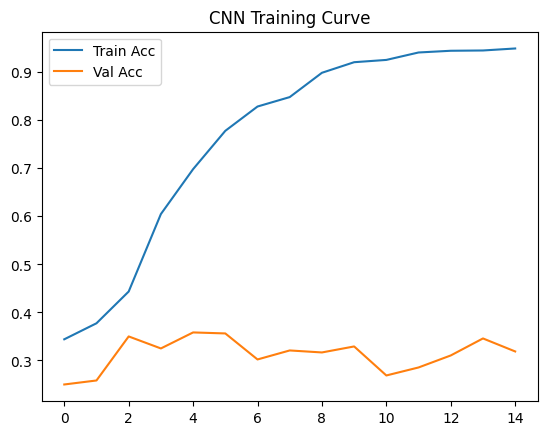

In [36]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("CNN Training Curve")
plt.legend()
plt.show()

In [1]:
# ===== STEP: BINARY LABEL MAPPING (GOOD vs BAD) =====

import pandas as pd

subject_info = pd.read_csv("subject-info.csv")
subject_info.columns = subject_info.columns.str.strip().str.lower()

subject_to_label_binary = {}

for _, row in subject_info.iterrows():
    subject_name = row['subject']   # Subject00
    label = int(row['count quality'])  # 0 or 1

    subject_id = subject_name.replace("Subject", "s").lower()

    subject_to_label_binary[subject_id] = label

print("Sample Binary Mapping:")
for k in list(subject_to_label_binary.keys())[:5]:
    print(k, "→", subject_to_label_binary[k])

FileNotFoundError: [Errno 2] No such file or directory: 'subject-info.csv'